In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,1)
        )
    def forward(self,x):
        return self.net(x)

In [3]:
def initial_condition(x,y):
    return torch.sin(torch.pi * x) * torch.sin(torch.pi * y)

def boundary_condition(x,y,t, custom_value):
    return torch.full_like(x, custom_value)

In [4]:
def generate_training_data(num_points):
    x = torch.rand(num_points, 1, requires_grad = True)
    y = torch.rand(num_points, 1, requires_grad = True)
    t = torch.rand(num_points, 1, requires_grad = True)
    
    return x,y,t

In [5]:
def generate_boundary_points(num_points):
    x_boundary = torch.tensor([0.0,1.0]).repeat(num_points//2)
    y_boundary = torch.rand(num_points)
    
    if torch.rand(1) > 0.5:
        x_boundary, y_boundary = y_boundary,x_boundary
        
    return x_boundary.view(-1,1), y_boundary.view(-1,1)


def generate_boundary_training_data(num_points):
    x_boundary, y_boundary = generate_boundary_points(num_points)
    t = torch.rand(num_points, 1, requires_grad= True)
    
    return x_boundary, y_boundary, t

In [6]:
def pde(x,y,t,model):
    input_data = torch.cat([x,y,t],dim=1)
    u = model(input_data)
    u_x,u_y = torch.autograd.grad(u,[x,y],grad_outputs= torch.ones_like(u), create_graph= True, retain_graph=True) 
    u_xx = torch.autograd.grad(u_x,x,grad_outputs= torch.ones_like(u_x), create_graph= True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y,y,grad_outputs= torch.ones_like(u_y), create_graph= True, retain_graph=True)[0]
    u_t = torch.autograd.grad(u,t,grad_outputs= torch.ones_like(u), create_graph= True, retain_graph=True)[0]
    heat_eq_residual = 1 * u_xx + 1 * u_yy - u_t
    return heat_eq_residual

In [7]:
def train_PINN(model, num_iterations, num_points):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    mse = nn.MSELoss()

    for iteration in range(num_iterations):
        optimizer.zero_grad()

        # Interior collocation points (for PDE residual)
        x, y, t = generate_training_data(num_points)

        # Boundary points
        x_b, y_b, t_b = generate_boundary_training_data(num_points)

        # Initial condition (t = 0)
        t_initial = torch.zeros_like(t)
        u_initial = initial_condition(x, y)

        # Boundary condition values (assume Dirichlet u = 0)
        custom_value = 0.0
        u_boundary = boundary_condition(x_b, y_b, t_b, custom_value)

        # PDE residual: R = u_t - (u_xx + u_yy)
        residual = pde(x, y, t, model)

        # Predictions from model
        u_pred_initial = model(torch.cat([x, y, t_initial], dim=1))
        u_pred_boundary = model(torch.cat([x_b, y_b, t_b], dim=1))

        # Loss terms
        loss_initial = mse(u_pred_initial, u_initial)
        loss_boundary = mse(u_pred_boundary, u_boundary)
        loss_pde = mse(residual, torch.zeros_like(residual))

        loss = loss_initial + loss_boundary + loss_pde

        # Backpropagation
        loss.backward()
        optimizer.step()

        if iteration % 100 == 0:
            print(f"Iteration {iteration}, Loss: {loss.item():.6f}")

In [8]:
model = PINN()
num_iterations = 10000
num_points = 1000
train_PINN(model,num_iterations,num_points)

Iteration 0, Loss: 0.235603
Iteration 100, Loss: 0.102095
Iteration 200, Loss: 0.100384
Iteration 300, Loss: 0.096784
Iteration 400, Loss: 0.096469
Iteration 500, Loss: 0.085146
Iteration 600, Loss: 0.074838
Iteration 700, Loss: 0.063921
Iteration 800, Loss: 0.059300
Iteration 900, Loss: 0.053110
Iteration 1000, Loss: 0.054281
Iteration 1100, Loss: 0.045691
Iteration 1200, Loss: 0.045792
Iteration 1300, Loss: 0.040479
Iteration 1400, Loss: 0.037894
Iteration 1500, Loss: 0.032727
Iteration 1600, Loss: 0.030684
Iteration 1700, Loss: 0.029362
Iteration 1800, Loss: 0.029805
Iteration 1900, Loss: 0.025843
Iteration 2000, Loss: 0.022177
Iteration 2100, Loss: 0.024495
Iteration 2200, Loss: 0.020549
Iteration 2300, Loss: 0.017329
Iteration 2400, Loss: 0.018193
Iteration 2500, Loss: 0.016105
Iteration 2600, Loss: 0.016918
Iteration 2700, Loss: 0.016060
Iteration 2800, Loss: 0.014960
Iteration 2900, Loss: 0.014604
Iteration 3000, Loss: 0.013684
Iteration 3100, Loss: 0.013257
Iteration 3200, Loss

/opt/anaconda3/envs/pytorch-py311/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


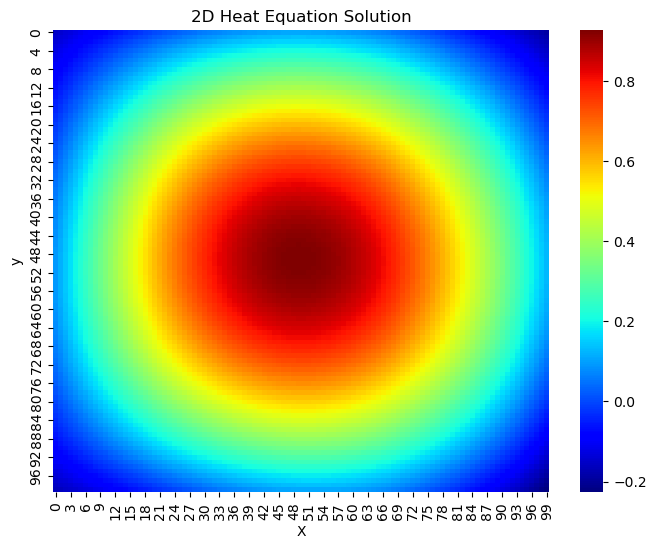

In [9]:
with torch.no_grad():
    x_vals = torch.linspace(0,1,100)
    y_vals = torch.linspace(0,1,100)
    X, Y = torch.meshgrid(x_vals,y_vals)
    t_val = torch.ones_like(X) * 0 # spacify the time
    
    input_data = torch.stack([X.flatten(),Y.flatten(),t_val.flatten()], dim=1)
    solution = model(input_data).reshape(X.shape,Y.shape)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(solution, cmap="jet")
    plt.title("2D Heat Equation Solution")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show()

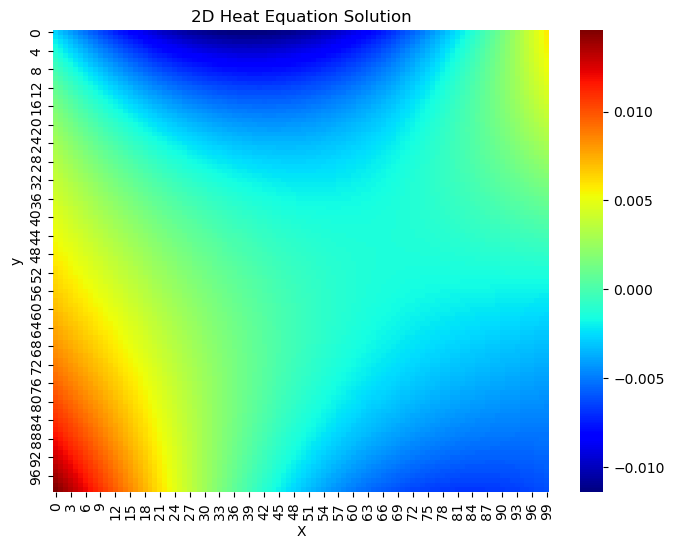

In [10]:
with torch.no_grad():
    x_vals = torch.linspace(0,1,100)
    y_vals = torch.linspace(0,1,100)
    X, Y = torch.meshgrid(x_vals,y_vals)
    t_val = torch.ones_like(X) * 1 # spacify the time
    
    input_data = torch.stack([X.flatten(),Y.flatten(),t_val.flatten()], dim=1)
    solution = model(input_data).reshape(X.shape,Y.shape)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(solution, cmap="jet")
    plt.title("2D Heat Equation Solution")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show()